In [8]:
# Imports and Configuration

import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="whitegrid")

REPORTS_DIR = Path("../outputs/metrics")

file_mapping = {
    "Run 2 (r8, lr1e-4)": "evaluation_report_lora_cloud_r8_lr1e-4.json",
    "Run 3 (r8, lr2e-4) [CHAMPION]": "evaluation_report_lora_cloud_r8_lr2e-4.json",
    "Run 4 (r16, lr1e-4)": "evaluation_report_lora_cloud_r16_lr1e-4.json",
    "Run 5 (r16, lr2e-4)": "evaluation_report_lora_cloud_r16_lr2e-4.json"
}

champion_col = "Run 3 (r8, lr2e-4) [CHAMPION]"

In [9]:
# Data Loading and Aggregation

aggregate_keys = ["micro avg", "macro avg", "weighted avg", "samples avg"]
data_frames = []

for run_name, filename in file_mapping.items():
    filepath = REPORTS_DIR / filename
    if not filepath.exists():
        print(f"File not found: {filepath}")
        continue
        
    with open(filepath, 'r', encoding='utf-8') as f:
        report = json.load(f)
        
    # Extract f1-scores for actual classes only
    f1_scores = {
        class_name: metrics["f1-score"] 
        for class_name, metrics in report["detailed_report"].items() 
        if class_name not in aggregate_keys
    }
    
    # Create a Series and append
    s = pd.Series(f1_scores, name=run_name)
    data_frames.append(s)

# Combine into a single DataFrame
df_f1 = pd.concat(data_frames, axis=1)

print("Data loaded successfully! Shape:", df_f1.shape)

Data loaded successfully! Shape: (19, 4)


In [10]:
RED = '\033[91m'
BOLD = '\033[1m'
RESET = '\033[0m'

print(f"\n{BOLD} LOWEST SCORES PER EXPERIMENT (RANKED){RESET}")

# Display all classes sorted from lowest to highest F1-score for each experiment
for col in df_f1.columns:
    print(f"\n{BOLD}{'='*50}{RESET}")
    print(f"{BOLD}Ranking for {col}{RESET}")
    print(f"{BOLD}{'='*50}{RESET}")
    
    # Sort ascending so the worst performers are at the top
    sorted_series = df_f1[col].sort_values(ascending=True)
    
    for class_name, score in sorted_series.items():
        if score > 0:
            score_str = f"F1: {score:.3f}"
        else:
            score_str = f"{RED}{BOLD}F1: 0.000 <-{RESET}"
            
        print(f"{class_name:<40} | {score_str}")


 LOWEST SCORES PER EXPERIMENT (RANKED)

Ranking for Run 2 (r8, lr1e-4)
I am a victim                            | F1: 0.000 <-
I am bad - dangerous, toxic, evil        | F1: 0.000 <-
I am bound to be rejected                | F1: 0.000 <-
I am immoral                             | F1: 0.000 <-
I am unattractive                        | F1: 0.000 <-
I am out of control                      | F1: 0.000 <-
I am needy                               | F1: 0.000 <-
I don’t deserve to live                  | F1: 0.000 <-
I am undesirable, unwanted               | F1: 0.125
I am a failure, loser                    | F1: 0.250
I am trapped                             | F1: 0.308
I am bound to be abandoned               | F1: 0.333
I am worthless, waste                    | F1: 0.333
I am unlovable                           | F1: 0.421
I am defective                           | F1: 0.462
I am bound to be alone                   | F1: 0.462
I am incompetent                         | F1: 0.500
I a

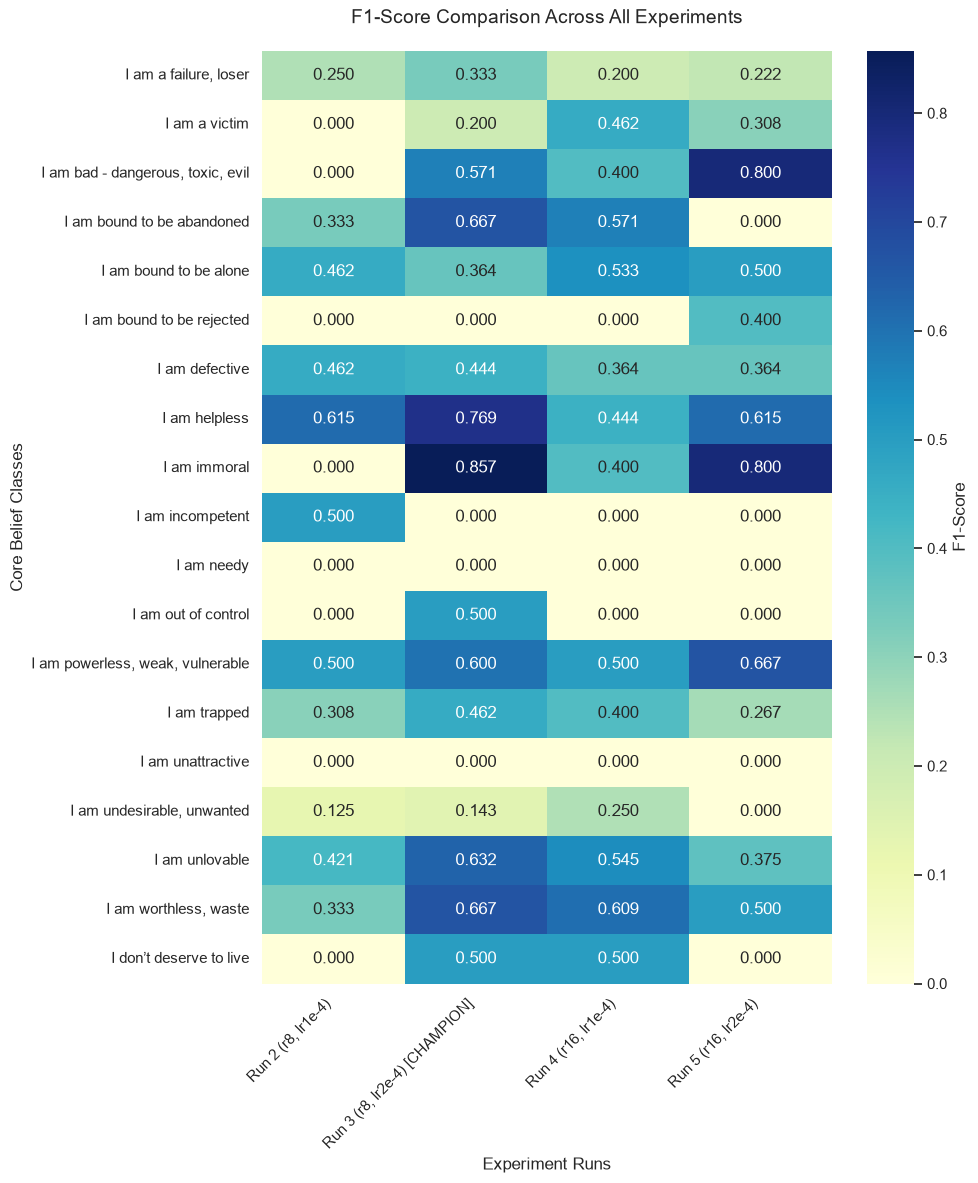

In [11]:
# Visualize the comparison across all runs
plt.figure(figsize=(10, 12))
sns.heatmap(df_f1, annot=True, cmap="YlGnBu", fmt=".3f", cbar_kws={'label': 'F1-Score'})
plt.title("F1-Score Comparison Across All Experiments", pad=20, fontsize=14)
plt.ylabel("Core Belief Classes", fontsize=12)
plt.xlabel("Experiment Runs", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
# Calculate the maximum F1-score any model achieved for a given class
df_f1['Max_Across_Runs'] = df_f1.max(axis=1)

high_priority = []
medium_priority = []
low_priority = []

# Define threshold for a "good" mapping by the champion model
CHAMPION_SUCCESS_THRESHOLD = 0.40

for class_name, row in df_f1.iterrows():
    max_score = row['Max_Across_Runs']
    champion_score = row[champion_col]
    
    # 1. High Priority: True Zeros or consistently near-zero (< 0.1 across ALL runs)
    if max_score < 0.1:
        high_priority.append((class_name, max_score))
        
    # 2. Low Priority: Champion already maps it nicely
    elif champion_score >= CHAMPION_SUCCESS_THRESHOLD:
        low_priority.append((class_name, champion_score))
        
    # 3. Medium Priority: Champion struggled, but signal exists (>0.1 somewhere)
    else:
        medium_priority.append((class_name, champion_score, max_score))

print(f"🚨 HIGH PRIORITY (Generate 50+ examples)")
print("These classes failed across ALL models (Max F1 < 0.1).")
for item in high_priority:
    print(f"  - {item[0]} (Max F1: {item[1]:.3f})")

print(f"\n⚠️ MEDIUM PRIORITY (Generate 20-30 examples)")
print("Champion struggled, but they showed life in other runs.")
for item in medium_priority:
    print(f"  - {item[0]} (Champion F1: {item[1]:.3f} | Best F1 overall: {item[2]:.3f})")

print(f"\n✅ Champion model maps these nicely (F1 >= {CHAMPION_SUCCESS_THRESHOLD}).")
for item in low_priority:
    print(f"  - {item[0]} (Champion F1: {item[1]:.3f})")

🚨 HIGH PRIORITY (Generate 50+ examples)
These classes failed across ALL models (Max F1 < 0.1).
  - I am needy (Max F1: 0.000)
  - I am unattractive (Max F1: 0.000)

⚠️ MEDIUM PRIORITY (Generate 20-30 examples)
Champion struggled, but they showed life in other runs.
  - I am a failure, loser (Champion F1: 0.333 | Best F1 overall: 0.333)
  - I am a victim (Champion F1: 0.200 | Best F1 overall: 0.462)
  - I am bound to be alone (Champion F1: 0.364 | Best F1 overall: 0.533)
  - I am bound to be rejected (Champion F1: 0.000 | Best F1 overall: 0.400)
  - I am incompetent (Champion F1: 0.000 | Best F1 overall: 0.500)
  - I am undesirable, unwanted (Champion F1: 0.143 | Best F1 overall: 0.250)

✅ Champion model maps these nicely (F1 >= 0.4).
  - I am bad - dangerous, toxic, evil (Champion F1: 0.571)
  - I am bound to be abandoned (Champion F1: 0.667)
  - I am defective (Champion F1: 0.444)
  - I am helpless (Champion F1: 0.769)
  - I am immoral (Champion F1: 0.857)
  - I am out of control (Cha